In [10]:
!pip install tensorflow opencv-python numpy pandas matplotlib pygame scikit-learn

In [11]:
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import pygame

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("deadskull7/fer2013")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013


In [13]:
import os
data = pd.read_csv(os.path.join(path, "fer2013.csv"))

print(data.head())
print("Dataset Shape:", data.shape)

   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...  Training
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...  Training
Dataset Shape: (35887, 3)


In [14]:
pixels = data['pixels'].tolist()

width, height = 48, 48

faces = []

for pixel_sequence in pixels:
    face = np.fromstring(pixel_sequence, dtype=int, sep=' ')
    face = face.reshape(width, height)
    faces.append(face)

faces = np.array(faces)

faces = faces / 255.0
faces = faces.reshape(-1,48,48,1)

emotions = pd.get_dummies(data['emotion']).values

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    faces,
    emotions,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)

Training Data: (28709, 48, 48, 1)


In [16]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(48,48,1)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(7,activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test,y_test)
)

Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 110s 238ms/step - accuracy: 0.2573 - loss: 1.7954 - val_accuracy: 0.3929 - val_loss: 1.5351
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 98s 217ms/step - accuracy: 0.4232 - loss: 1.5035 - val_accuracy: 0.4776 - val_loss: 1.3493
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 140s 214ms/step - accuracy: 0.4826 - loss: 1.3572 - val_accuracy: 0.5109 - val_loss: 1.2730
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 138s 205ms/step - accuracy: 0.5207 - loss: 1.2621 - val_accuracy: 0.5322 - val_loss: 1.2304
Epoch 5/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 91s 203ms/step - accuracy: 0.5333 - loss: 1.2220 - val_accuracy: 0.5429 - val_loss: 1.2073
Epoch 6/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 95s 211ms/step - accuracy: 0.5593 - loss: 1.1651 - val_accuracy: 0.5603 - val_loss: 1.1718
Epoch 7/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 91s 202ms/step - accuracy: 0.5719 - loss: 1.1145 - val_accuracy: 0.5589 - val_loss: 1.1689
Epoch 8/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 151s 222ms/step - accuracy: 0.5930 - los

In [19]:
model.save("emotion_model.h5")
print("Model Saved")

Model Saved


In [20]:
emotion_labels = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Sad",
    "Surprise",
    "Neutral"
]

In [ ]:
music/
   happy.mp3
   sad.mp3
   angry.mp3
   neutral.mp3

Since webcam access is not available in Colab, we will modify the code to detect emotions from a static image file. Please upload an image file (e.g., `test_image.jpg`) to your Colab environment for testing.

Saving e.jfif to e.jfif
Uploaded file: e.jfif


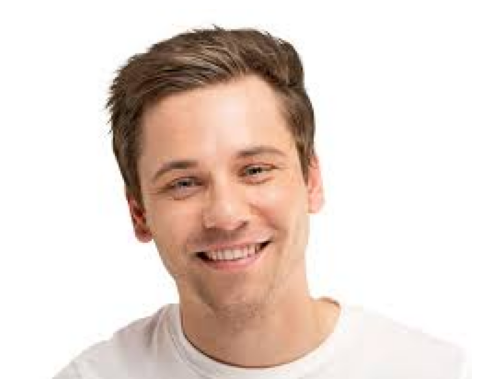

In [44]:
from google.colab import files
import io
from PIL import Image

# Upload a file from your local system
uploaded = files.upload()

# Assuming you upload one image, get its filename
image_filename = next(iter(uploaded))
print(f"Uploaded file: {image_filename}")

# To verify, you can display the image
img = Image.open(io.BytesIO(uploaded[image_filename]))
plt.imshow(img)
plt.axis('off')
plt.show()

Now, let's adapt the emotion detection

*   List item
*   List item

code to use this uploaded image instead of the webcam.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
Detected Happy, would play: music/happy.mp3


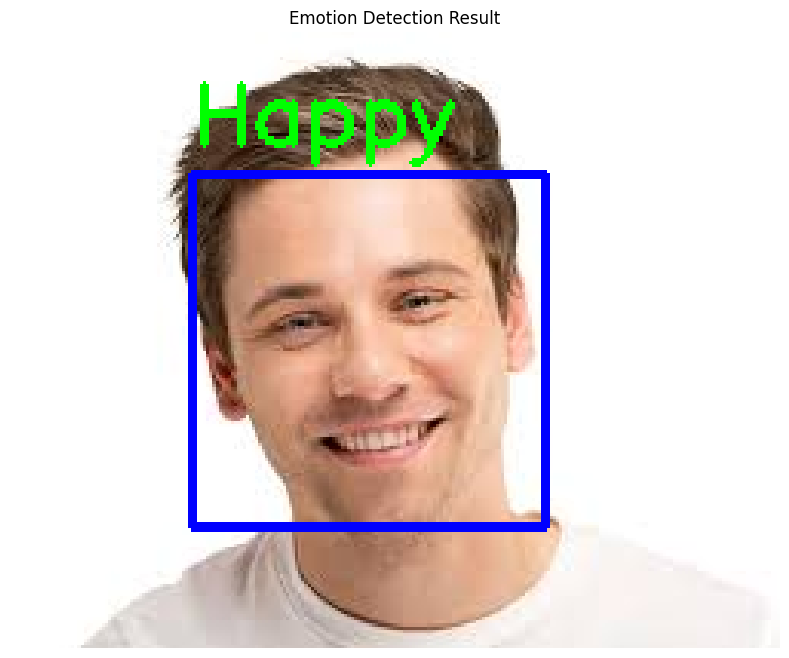

In [45]:
from tensorflow.keras.models import load_model

# Ensure the model is loaded if not already in memory
# model = load_model("emotion_model.h5") # Uncomment and run this if you restarted the kernel

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Read the uploaded image
image_path = image_filename # Use the filename from the uploaded file
frame = cv2.imread(image_path)

if frame is None:
    print(f"Error: Could not load image from {image_path}")
else:
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        face_roi = gray[y:y+h, x:x+w]
        face_roi = cv2.resize(face_roi, (48, 48))
        face_roi = face_roi / 255.0
        face_roi = face_roi.reshape(1, 48, 48, 1)

        prediction = model.predict(face_roi)
        emotion_index = np.argmax(prediction)
        emotion = emotion_labels[emotion_index]

        cv2.putText(frame, emotion, (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.9, (0, 255, 0), 2)

        if emotion in emotion_music:
            print(f"Detected {emotion}, would play: {emotion_music[emotion]}")

        cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)

    # Display the result using matplotlib instead of cv2.imshow
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib
    plt.axis('off')
    plt.title('Emotion Detection Result')
    plt.show()

In [21]:
emotion_music = {
    "Happy": "music/happy.mp3",
    "Sad": "music/sad.mp3",
    "Angry": "music/angry.mp3",
    "Neutral": "music/neutral.mp3"
}